<a href="https://colab.research.google.com/github/RonakkudalAI/Practical-Machine-Learning/blob/main/Mall_Customer(Clustering_by_Pca).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA




In [104]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [106]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [107]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [108]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [109]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [110]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Age', ylabel='count'>

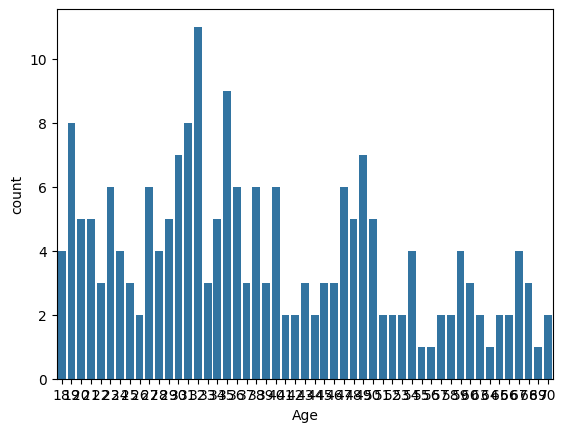

In [111]:
sns.countplot(x='Age',data=df)

<Axes: >

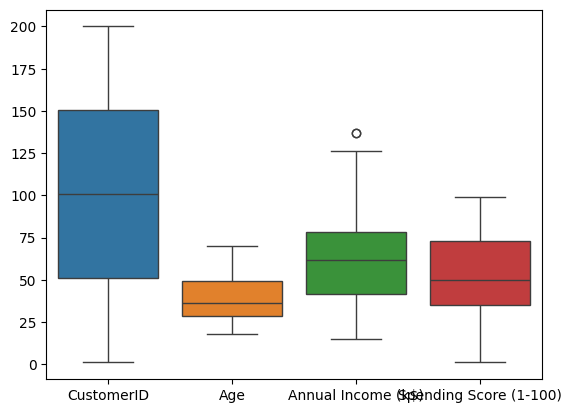

In [112]:
sns.boxplot(df)

In [113]:
df = df.drop('CustomerID',axis = 1)

In [114]:
df.duplicated().sum()

np.int64(0)

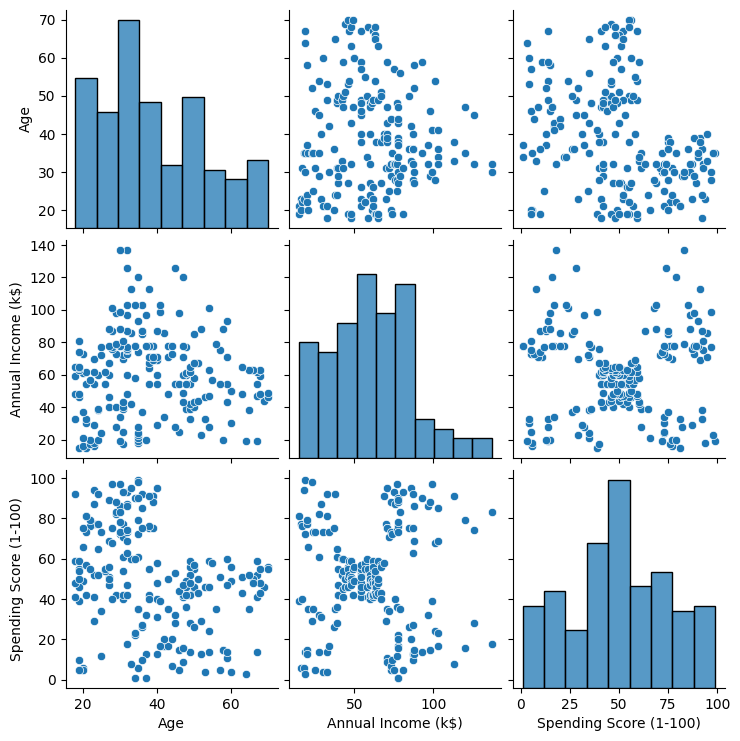

In [115]:
sns.pairplot(df)

In [116]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Genre'])

In [117]:
df = df.drop('Genre',axis = 1)

<Axes: xlabel='Gender', ylabel='count'>

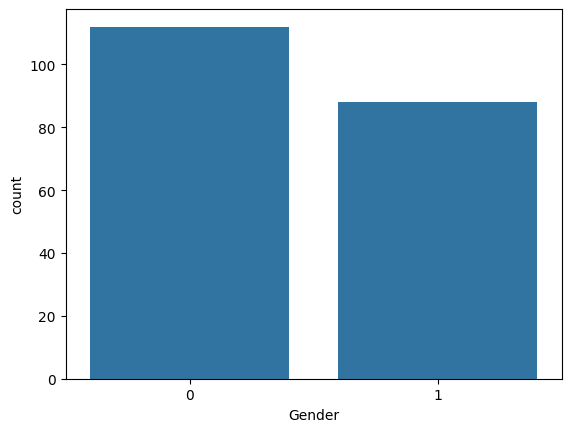

In [118]:
sns.countplot(x='Gender',data = df)

<Axes: xlabel='Age', ylabel='Count'>

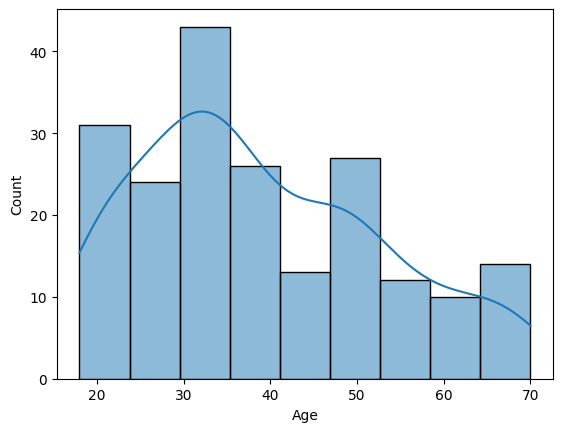

In [119]:
sns.histplot(data=df, x='Age', kde=True)

<Axes: >

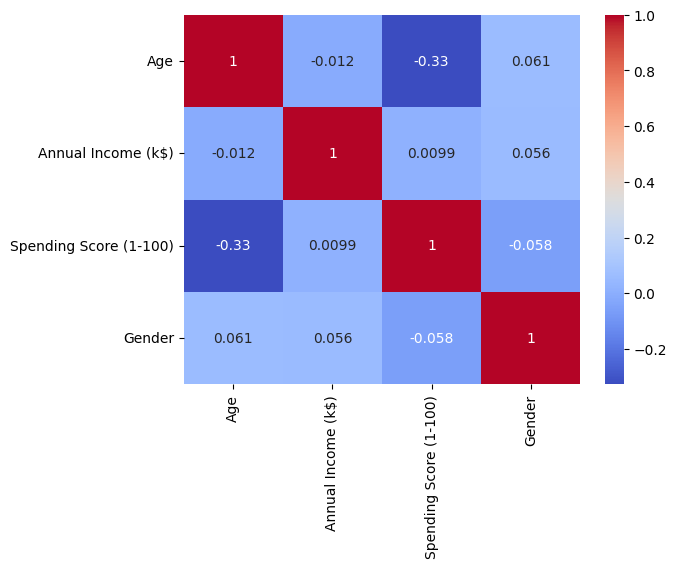

In [120]:
sns.heatmap(df.corr(),annot=True,cmap = 'coolwarm')

<Axes: >

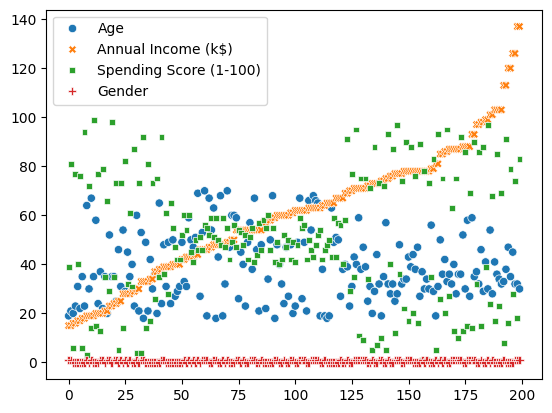

In [141]:
sns.scatterplot(df)

In [121]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x = sc.fit_transform(df)

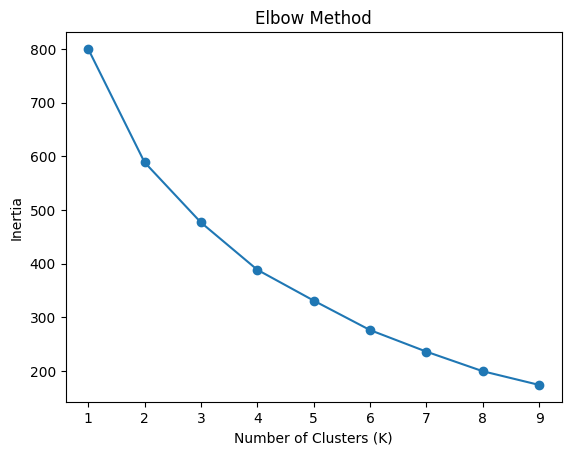

In [123]:
from sklearn.cluster import KMeans
intertia =[]

for k in range (1,10):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init = 10)
  kmeans.fit(x)
  intertia.append(kmeans.inertia_)

plt.plot(range(1,10),intertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

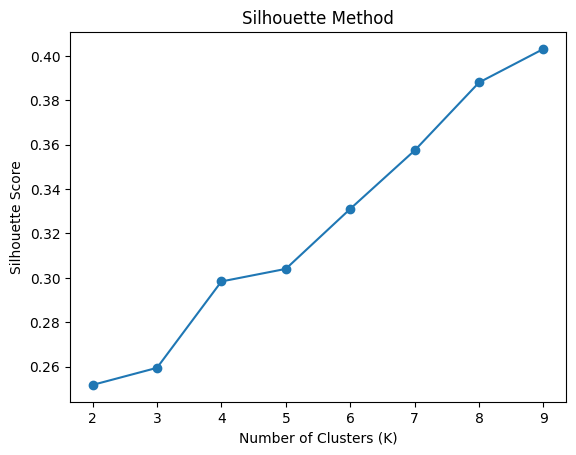

In [129]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(x)

    score = silhouette_score(x, labels)
    silhouette_scores.append(score)

# Plot
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

In [130]:
best_k = range(2, 10)[silhouette_scores.index(max(silhouette_scores))]
print("Best K:", best_k)
print("Best Score:", max(silhouette_scores))

Best K: 9
Best Score: 0.40309165116555223


In [136]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(x)

In [133]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

In [134]:
centroids = kmeans.cluster_centers_

# Convert to PCA space
centroids_pca = pca.transform(centroids)

/tmp/ipykernel_4735/147549354.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


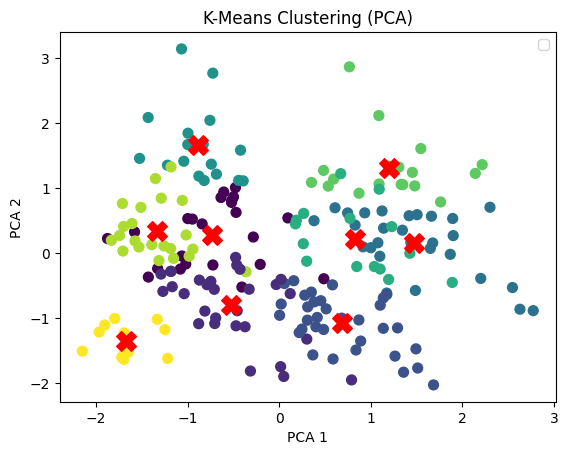

In [140]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50)

# Plot centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', s=200, marker='X')

plt.title("K-Means Clustering (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()